In [1]:
%load_ext autoreload
%autoreload 2

model_names = ['optstate', 'nooptstate', 'optstate_base']

eval_mat_dict = {}
for model_name in model_names:
    import dill
    with open(f'data/waic_ll_data_{model_name}.pkl', 'rb') as f:
        eval_mat_dict[model_name] = dill.load(f)

In [19]:
from gvabm.waic_eval import estimate_PLLD, estimate_WAIC_correction, WAIC_metric
from gvabm.city_data import subsample_weights, subsampled_city_data

eval_mat = eval_mat_dict['optstate_base']
plld, pld_per_datapoint = estimate_PLLD(eval_mat, subsample_weights)
print(f'Optstate Model PLLD: {plld}, per datapoint: {pld_per_datapoint.mean()}')

import numpy as np
min_ind = np.argmin(pld_per_datapoint)
print(subsampled_city_data[min_ind], pld_per_datapoint[min_ind])
max_ind = np.argmax(pld_per_datapoint)
print(subsampled_city_data[max_ind], pld_per_datapoint[max_ind])

Optstate Model PLLD: -1173.3586478036123, per datapoint: -2.2370412152334853
{'events': [EventOutcome(year=2014, fatalities=6, injured=-1, total_victims=-1, population=17718.0, population_density=131.50899085286608), EventOutcome(year=2006, fatalities=8, injured=-1, total_victims=-1, population=17718.0, population_density=131.50899085286608)], 'params': CityParams(year=2006, population=17718.0, population_density=131.50899085286608, arm_count=25.0, arm_density=0.012738853503184714), 'name': ('California', 'Santa Barbara County')} -17.687178621979907
{'events': [], 'params': CityParams(year=2020, population=17.0, population_density=0.2215746016593721, arm_count=6.000000000000001, arm_density=0.003057324840764331), 'name': ('North Dakota', 'Cavalier County')} -1.2084722103011813e-06


In [18]:
print(np.min(pld_per_datapoint), np.max(pld_per_datapoint))

-17.687178621979907 -1.2084722103011813e-06


{'events': [], 'params': CityParams(year=2000, population=1698201.5, population_density=1505.39290531307, arm_count=181.0, arm_density=0.09222929936305732), 'name': ('California', 'Los Angeles County')} -0.2655939646362242
{'events': [], 'params': CityParams(year=2020, population=17.0, population_density=0.2215746016593721, arm_count=6.000000000000001, arm_density=0.003057324840764331), 'name': ('North Dakota', 'Cavalier County')} -1.2084722103011813e-06


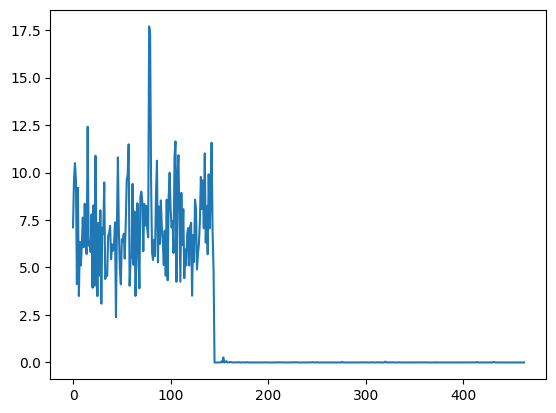

In [14]:
import matplotlib.pyplot as plt
# plt.plot(-pld_per_datapoint)
plt.plot(-pld_per_datapoint)
# plt.yscale('log')
plt.show()

In [20]:

from gvabm.waic_eval import estimate_PLLD, estimate_WAIC_correction
from gvabm.city_data import subsample_weights

for model_name in model_names:
    eval_mat = eval_mat_dict[model_name]
    plld, pld_per_datapoint = estimate_PLLD(eval_mat, subsample_weights)
    waic_correction, waic_correction_per_datapoint = estimate_WAIC_correction(eval_mat, subsample_weights)
    print(f'Model: {model_name}')
    print(f'  PLLD: {plld:.2f}')
    print(f'  WAIC correction: {waic_correction:.2f}')
    print(f'Total score (PLLD - WAIC correction): {plld - waic_correction:.2f}\n')
    waic, waic_se = WAIC_metric(eval_mat, subsample_weights)
    print(f'  WAIC: {waic:.2f} +/- {waic_se:.8f}\n')

Model: optstate
  PLLD: -1143.47
  WAIC correction: 3.25
Total score (PLLD - WAIC correction): -1146.71

  WAIC: -1146.71 +/- 0.27602934

Model: nooptstate
  PLLD: -1140.97
  WAIC correction: 3.08
Total score (PLLD - WAIC correction): -1144.05

  WAIC: -1144.05 +/- 0.27529456

Model: optstate_base
  PLLD: -1173.36
  WAIC correction: 5.12
Total score (PLLD - WAIC correction): -1178.48

  WAIC: -1178.48 +/- 0.28187889



In [ ]:
# WAIC Baseline: -1202.06 +/- 0.28537594